# Modeling, comparisons, feature importances.

## Exploratory Data Analysis.

Load in libraries:

In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid, GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import f1_score, accuracy_score,precision_score,recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from decision_tree import DecisionTree
import tqdm
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

Do some simple analytics of the dataset: check for nulls, datatypes, deviations, counts, medians, quartiles...

In [20]:
df = pd.read_csv("churn-data.csv")
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure              float64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [21]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1.0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34.0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2.0,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45.0,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2.0,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [22]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.940557,0.872582,0.789249,0.905859,0.903868,0.796359,0.984926,0.992890,0.688567,0.592719,1.573237,64.798208,2283.300441,0.265785
std,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.948627,0.737271,0.859962,0.880394,0.880178,0.861674,0.885285,0.885385,0.832934,0.491363,1.067504,30.085974,2266.771362,0.441782
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,35.587500,401.450000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.862500,3794.737500,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000


In [23]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No nulls.

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   float64
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  Monthl

All columns have same amount of values, 3 float values ( continuous factors ), 17 integers ( qualitative factors ). No nulls.

After running quick EDA using Pandas, it is found that the dataset contains: No nulls/nans. Has uneven distribution of churn versus non-churn customers (about 1/4 customer churn), leading to the thought that stratification might be quite important. Even distribution of genders. Few senior citizens. Relatively high sample variance in tenure, medium sample variance in total charges. Most customers have used tech support at least once, and there is a somewhat high variance in tech support need, which might suggest high tech support count customers might have higher chance for churn ( Customers churn after needing help too many times). Many of the predictor variables have relatively high variance with regards to the mean, which leads to the suspicion that it might be hard for a decision tree to get good metrics due to the high variances. Scaling the features won't help here as decision trees are invariant to monotonic scale transformations, scaling all values in a column by 100 will just make the threshold 100 times higher as well.


----------------

## Training the models, and model selection.

There are only two specific hyperparameters implemented in the task, namely, the "gain", here being Information Gain (Entropy based) and Gini Gain/Impurity (Gini index based), and the depth/height of tree. We can tune in the dimensions of gain (qualitatively, discretely), and the depth of the tree (on/off, if on: non-negative, discretey), giving a wide range to tune the options in.  This lends itself quite nicely towards Grid search cross validation. If the range were wider randomized / quasi monte carlo methods would've performed better timewise. The dataset is fitting in size with regards to cross validation training time, and would greatly benefit from the averaging out ( and look into variance, i.e. overfitting ) of hyperparameters that cross validation brings as decision trees are notoriously benevolent to overfitting to noise. Further, the size of the dataset only being ~7000 rows on a tabular dataset brings is not a huge dataset which justifies a proper usage of hold out validation. Having e.g. 20% set away for validation only uses ~1400 rows of data, which can bring in a couple of percentages in deviation in metrics, which is not ideal here. Amongst cross validation techniques, the most obvious is the simple stratified k-fold since the data is not time-based nor grouped nor anything similar, which would've inherently meant that the order the data is passed in would've mattered. Stratification is important here for a very specific reason, the data is not evenly distributed amongst the classes. We can easily see this by the fact that the mean is not 0.5 in the churn column in the description above. Hence, to be able to accurately capture some similar distribution for each training fold we need to resort to stratification.

To note on metrics. Precision and recall are of high importance here, as precision would give insight into how many of the people the model expected to churn actually churned, and recall is of high importance as that gives insight into how many were expected to churn when looking at all the people that actually churned (regardless of model expectation). F1 score gives a very balanced overview of these two. We want high precision, recall and F1. Accuracy is of lesser importance, as accuracy also focuses on the correctness regarding not-churning, and a company would not mind retaining a customer they expected to churn, but the other case where a customer whom wasn't expected to churn ended up churning. The former case brings no negatives, but the latter is something that a company would like to try to prevent. Using for example promotional codes, or discounts, in an attempt to convince an expected-churn customer to stay and continue being a customer.

In [25]:
seed = 1234

In [26]:
x = df.drop(columns="Churn")
y = df["Churn"]

In [27]:
x, x_test, y, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=seed)

Set aside 20% of the original data for testing after model selection.

------------------------

### Helper functions.

In [28]:
def evaluate_model(y_true, y_preds):
    """Returns qualitative evaluation metrics for a model's predictions."""
    return {
        "accuracy":accuracy_score(y_true,y_preds),
        "f1":f1_score(y_true,y_preds, zero_division=0, average="binary"),
        "precision":precision_score(y_true,y_preds, zero_division=0, average="binary"),
        "recall":recall_score(y_true,y_preds, average="binary")
    }


In [29]:
def evaluate_folds(scores):
    """Aggregates each metric's mean and standard deviation across folds."""
    metrics = {}
    for metric in scores[0]:
        values = [score[metric] for score in scores]
        metrics[f"{metric}_mean"] = np.mean(values)
        metrics[f"{metric}_std"] = np.std(values, ddof=1)
    return metrics

In [30]:
def plot_confusion_matrix(model, X_test, y_test, normalized=True):
    """Plots a confusion matrix on test data with a model."""
    fig, ax = plt.subplots()

    #Get predictions.
    predictions = model.predict(X_test)

    #Get confusion matrix from predictions.
    matrix = confusion_matrix(y_test,predictions,normalize="true" if normalized==True else None)
    disp = ConfusionMatrixDisplay(matrix)
    
    #Plot confusion matrix.
    disp.plot(ax=ax)
    fig.tight_layout()
    plt.show()

In [31]:
def select_best_model(models_metrics, models, metric="f1_mean"):
    """Selects the best model from models using the model's metrics."""
    best_key = models_metrics[metric].idxmax()
    return (models[best_key], dict(best_key))

------------------------

## Training models.

### Dummy Classifier.

First we start by creating a very simple dummy classifier to have some form of baseline to compare to, here there exists several different dummy classifier models we can choose from. Using Sklearn, we can use the `DummyClassifier` model which has several prediction strategies: `most_frequent`, `prior`, `stratified`, `uniform` and `constant`. Since our dataset is quite unbalanced towards non-churn, simply predicting the most common label, "non-churn", like `most_frequent` and `prior` does, will produce 0 in recall, and precision. Which are the metrics we are most interested in for this problem statement. Uniform simply guesses a class uniformly for each row. Constant just predicts the same constant for all rows. Stratified might act the most fittingly here for a baseline as that strategy is specifically made for unbalanced datasets. Nonetheless, the dummyclassifier must be trained with stratified cross validation just like the other models to ensure fair comparison.

As Sklearn's built-in GridSearchCV only works on Sklearn's built in models, or models fitted to work with the sklearn framework (which is a hassle considering task 1), we can naively implement gridsearchcv ourselves using ParameterGrid to get all the possible parameter permutations, and StratifiedKFold to get all the stratified folds in the cross validation folds.

Perform training using strafified kfold with 5 folds, and setting random state to seed to ensure reproducability. (Also possible to use RepeatedStratifiedkFold which is identical to a simple stratified k-fold but it goes over all folds multiple times rather than just once, but negligible differences were observed testing this in terms of metrics and metric deviations, )

In [32]:
def cross_validate_models(model, param_grid, x, y,  folds=5, seed=None):
    """Cross validates, and refits, a model function on a parameter grid using x feature set, and y label set."""
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    param_list = list(ParameterGrid(param_grid))
    metrics = {}
    models={}

    # Train and evaluate one model per parameter combination.
    for params in tqdm.tqdm(param_list, desc="Model training"):
        scores = []

        # Cross-validate this parameter combination across folds.
        for i, (train_index, val_index) in enumerate(skf.split(x, y)):
            X_tr, X_val = x.iloc[train_index], x.iloc[val_index]
            y_tr, y_val = y.iloc[train_index], y.iloc[val_index]
            tree = model(**params)
            tree.fit(X_tr,y_tr)
            predictions = tree.predict(X_val)
            scores.append(evaluate_model(y_val,predictions))

        # Use frozenset so params dict (unhashable) can key a dict.
        key = frozenset(params.items())
        
        # Record params alongside aggregated fold scores for this combination.
        tree_metrics = params.copy()
        tree_metrics.update(evaluate_folds(scores))

        # Refit on the full dataset for the final, deployable model.
        trained_model = model(**params)
        trained_model.fit(x,y)

        models[key]=trained_model
        metrics[key]=tree_metrics
        
    metrics = pd.DataFrame.from_dict(metrics, orient="index")
    return (metrics,models)

In [33]:
dummy_params_grid= {
    "strategy":["most_frequent","prior","stratified","uniform"],
    "random_state":[seed]
}

dummy_classifier_metrics, dummy_classifier_models = cross_validate_models(DummyClassifier, dummy_params_grid, x, y, folds=5, seed=seed)

Model training: 100%|██████████| 4/4 [00:00<00:00, 13.11it/s]


In [34]:
best_dummy, best_dummy_params  = select_best_model(dummy_classifier_metrics, dummy_classifier_models)
print(best_dummy_params)

{'random_state': 1234, 'strategy': 'uniform'}


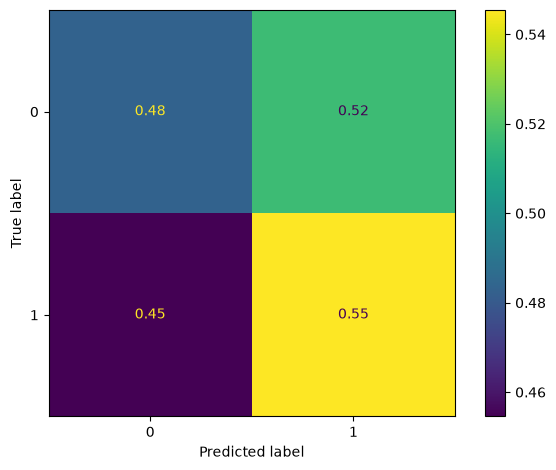

In [35]:
plot_confusion_matrix(best_dummy,x_test,y_test)

-----------------------------------

### Custom Decision Tree Classifier Training.

In [36]:
tree_params_grid = {
    "max_depth":list(range(1,31)) + [None],
    "criterion":["entropy","gini"]
}

custom_trees_metrics, custom_trees_models = cross_validate_models(DecisionTree, tree_params_grid, x, y, folds=5, seed=seed)

Model training: 100%|██████████| 62/62 [05:04<00:00,  4.91s/it]


Make dataframe of models, and pivot with regards to metrics for easy plotting.

In [37]:
custom_trees_metrics.head(5)

,criterion,max_depth,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
"frozenset({(max_depth, 1), (criterion, entropy)})",entropy,1.0,0.734222,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"frozenset({(max_depth, 2), (criterion, entropy)})",entropy,2.0,0.739911,0.014614,0.596669,0.021295,0.507659,0.019655,0.723746,0.026504
"frozenset({(max_depth, 3), (criterion, entropy)})",entropy,3.0,0.777422,0.008493,0.512668,0.034118,0.612088,0.015948,0.442140,0.044771
"frozenset({(criterion, entropy), (max_depth, 4)})",entropy,4.0,0.771200,0.007840,0.514504,0.054773,0.590809,0.024220,0.464883,0.106421
"frozenset({(criterion, entropy), (max_depth, 5)})",entropy,5.0,0.796267,0.007553,0.562257,0.028227,0.654684,0.013402,0.493645,0.040106


To get an overview of the different models trained we can put up some simple plots per depth level. Notice: when `max_depth` is None, i.e. the model trains until all leaves are pure, a decision has been made to **not** plot this as None is not technically a discrete value for depth and therefore does not have a natural order in a the depth axis.

Therefore: it is important to use the plots for a general overview of the occuring trends when `max_depth` increases, and the table above to get a good understanding of how this relates to the other case where it's trained until all leaves are pure. Since the model often reaches pure leaves for high enough max_depth settings, the None case gets approxiamated for high depths, as can be seen when the curves flatten out.

Since the models split on the median of the best column, if every split partitions the data roughly in half, then after depth $d$ each leaf contains around $\frac{n}{2^d}$ rows. With ~7030 training rows, leaves become nearly pure around depth $\log_2(7030) \approx 13$, which is roughly where the curves begin to flatten. In practice the flattening happens a bit later, since median splits don't always divide the data perfectly evenly. Here we train up to 30.

In [38]:
def plot_tree_metrics(tree_metrics, metrics=None, criterions=None):
    if metrics is None:
        metrics = ["f1","recall","precision","accuracy"]
    if criterions is None:
        criterions = ["entropy","gini"]

    #Get plotting cells.
    cols = 2
    rows  = math.ceil(len(metrics) / cols)
    figure, subplot_axes = plt.subplots(rows,cols,figsize=(8*cols,4*rows))
    subplot_axes = subplot_axes.flatten()

    # Group rows by criterion, keeping only the ones requested, sorted for clean line plots.
    metrics_by_criterion = {
        criterion: group.sort_values("max_depth")
        for criterion, group in tree_metrics.groupby("criterion")
        if criterion in criterions
    }

    # One subplot per metric, one line per criterion within it.
    for axis, metric in zip(subplot_axes, metrics):
        for criterion, group in metrics_by_criterion.items():
            axis.errorbar(
                group["max_depth"],
                group[f"{metric}_mean"],
                yerr=group[f"{metric}_std"],
                label=criterion.capitalize(),
                marker="o",
                linestyle="--",
                capsize=4,
            )
        
        #Plot.
        axis.set_title(f"Sample {metric} mean and standard deviation by parameters. ")
        axis.set_xlabel("Max Depth")
        axis.set_ylabel(f"{metric}")
        axis.legend(title="Criterion")
        axis.grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

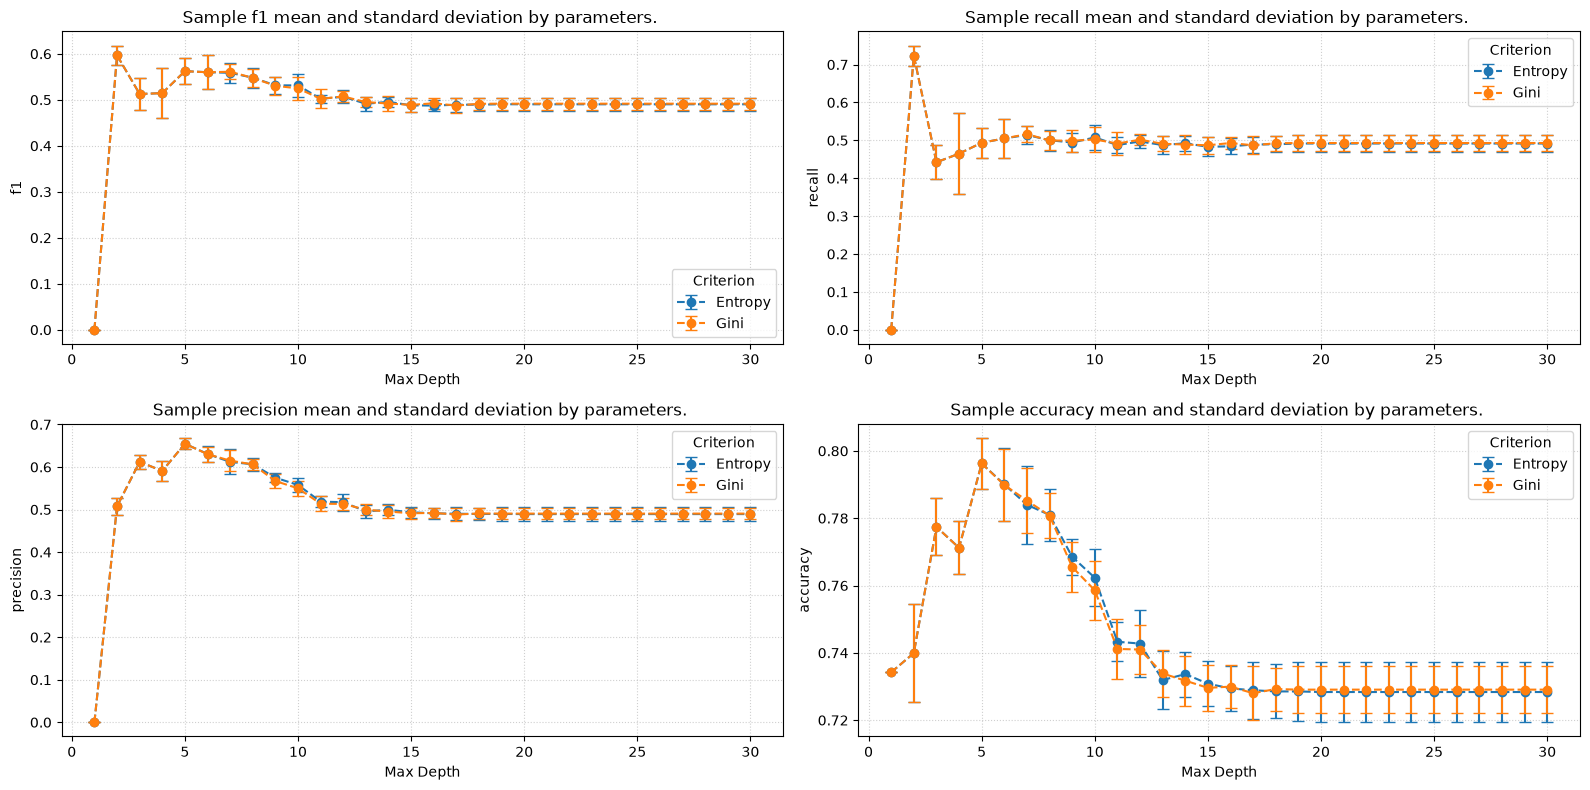

In [39]:
plot_tree_metrics(custom_trees_metrics)

To provide some discussion on the plots and the insights they give there are a couple of trends to discuss. First of all, both Entropy and Gini seems to give quite similar results for all metrics. There is a notable spike at depth = 2 for the recall, where we have 4 splits in total. The exact reason for this is uncertain as of right now, but is suspected to be related to the churn distribution being 1/4 of the total customer, and having 4 splits for depth=2. In other words, the model finds a naive but decent split to predict churns at this level, but this faulters away when the depth first increases as the noise overtakes, later on it recovers as the model becomes more complex and can handle more complex noisy patterns. The other models have an expected curve when taking the bias-variance tradeoff into consideration. Low start where the model underfits and doesn't capture trends, an upwards curve where the model manages to capture general trends, a curve downwards to a flattening where the model has overfitted to the training data and now struggles to capture the general trend in the validation data. This is clear in many of the plots here. Especially, precision and accuracy. Less so for recall, and therefore also for the F1 score. Notably it should be mentioned that accuracy on depth=1 is just the value of churn versus not churn as the model has not split yet so it guesses the most common label and gets good accuracy as follows. This is a known fault of accuracy metrics when the data is not evenly distributed in predicted classes, such as in this case.

As both recall and precision are both important metrics here, we will use F1 score as the deciding metric on what model is the best.

In [40]:
best_custom_tree, best_custom_tree_params = select_best_model(custom_trees_metrics, custom_trees_models)
print(best_custom_tree_params)

{'max_depth': 2, 'criterion': 'entropy'}


The best parameter set of our custom Decision Tree implementation has the criterion as *Entropy*, and the max depth as *2*.

### Custom Decision Tree Model evaluation on Testing set.

In [41]:
evaluate_model(y_test, best_custom_tree.predict(x_test))

{'accuracy': 0.7292110874200426,
 'f1': 0.5675368898978433,
 'precision': 0.4930966469428008,
 'recall': 0.6684491978609626}

Here we can see that the metrics of the full model trained on the full training set using the optimal parameter set evaluated on the test data, gives quite similar results to the metrics gotten from the cross validation. Taking into considertaiton that churned people only make up about 1/4 of the entire dataset these metrics are quite decent, and will give an edge to the company that employs them.

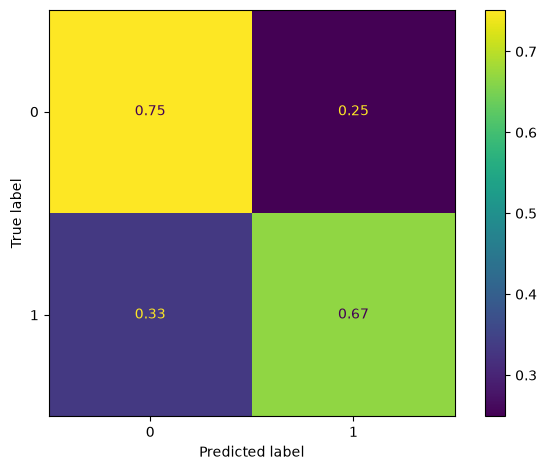

In [42]:
plot_confusion_matrix(best_custom_tree,x_test,y_test)

--------------------------------

## Comparison to Sklearn `DecisionTreeClassifier`.

Since finding the best decisiontree is an NP problem, there is no simple polynomial time way to find the optimal decision tree. Therefore, there is a wide range of different algorithms to find a good decision tree model for a dataset. The most common industry-standard models, some of them ensemble models, include Adaboost ( mostly legacy usage), XGBoost, Catboost, LightGBM ( giving similar results to XGBoost), and the easier Sklearn `DecisionTreeClassifier` - which is the one we will use here for comparison.

To ensure fair comparison we train using our custom `cross_validate_models` function instead of relying on the built-in GridSearchCV. This also allows us to get a plot of means and standard deviations for all metrics over each depth.

In [43]:
decision_trees_metrics, decision_trees_models = cross_validate_models(DecisionTreeClassifier, tree_params_grid, x, y, folds=5, seed=seed)

Model training: 100%|██████████| 62/62 [00:09<00:00,  6.63it/s]


In [44]:
best_decision_tree, best_decision_tree_params = select_best_model(custom_trees_metrics, custom_trees_models)
print(best_decision_tree_params)

{'max_depth': 2, 'criterion': 'entropy'}


We get identical model parameters! Something must, nonetheless, be noted! In our model we always split on the median for a feature, instead of finding the best split threshold for the feature as that is somewhat more computationally heavy. The task also specifies that optimal splitting is not a requirement, and that the median or mean can be used instead as these give decent location of centers (which themselves are good "best split threshold" approximates, to use as thresholds). DecisionTreeClassifier in Sklearn does, however, not do this. This classifier can take in a parameter called "splitter" which has two permitted values; "best", and "random". Best means the model splits on the optimal threshold for the features to divide the data according to what brings highest entropy/gini gain after splitting, whilst our median model does not guarantee this. This inherently means that the models might give different optimal criterions and depths, though they will quite often give very similar results. Actually here, identical results on the test set.

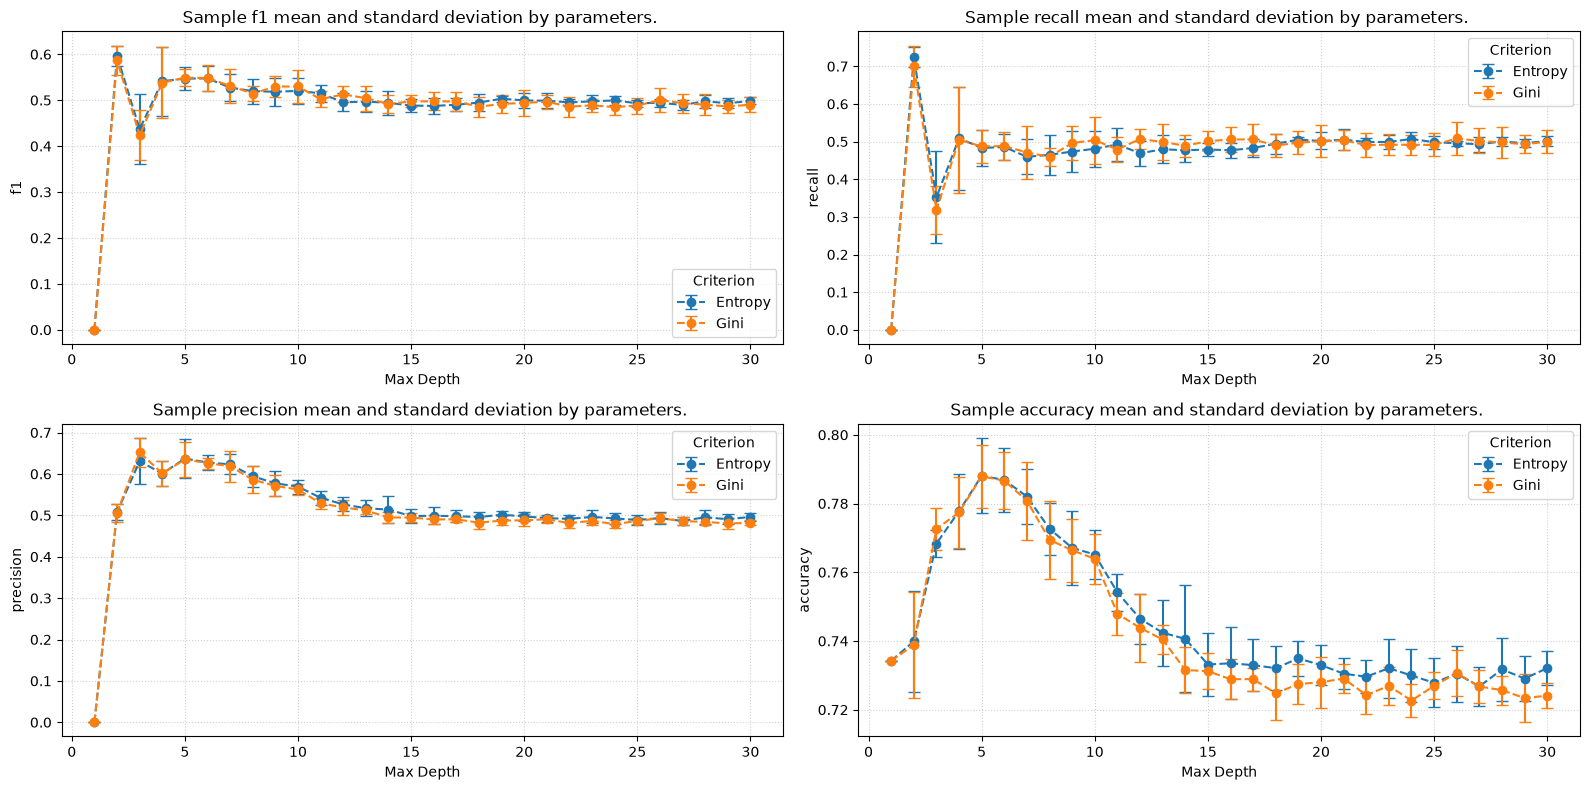

In [45]:
plot_tree_metrics(decision_trees_metrics)

Since the test dataset used for the custom models and the sklearn models is the same, we expect the same trends to show up. Notably, the sklearn models are also more noisy at the same depths between entropy and gini since they search for the optimal split threshold at each node, whereas the custom implementation only split on the mean. Therefore, the sklearns models have higher differences between the two criteria, since it's much more sensitive to the impurity measure.


In [46]:
evaluate_model(y_test, best_decision_tree.predict(x_test))

{'accuracy': 0.7292110874200426,
 'f1': 0.5675368898978433,
 'precision': 0.4930966469428008,
 'recall': 0.6684491978609626}

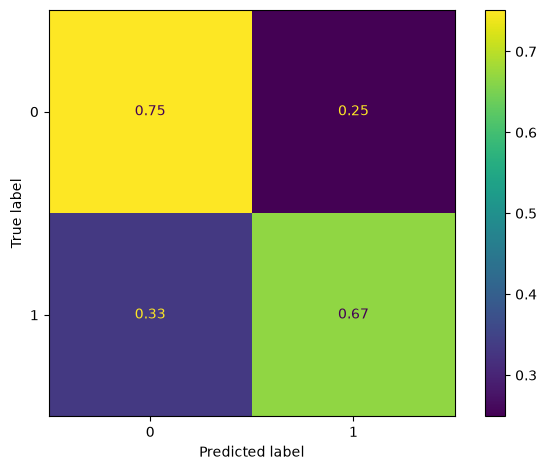

In [47]:
plot_confusion_matrix(best_decision_tree,x_test,y_test)

------------------------------------------------------------------

## Feature Importance.

To evaluate which features are important for a model, "permutation feature importance" is a metric which assigns importances to each feature of a model, giving output in form a custom chosen metric (e.g. R2 for regression models, F1 score for decision trees). It works by corrupting each feature column in a dataset K times by shuffling randomly around and destroying any order between the feature and the output metric. If a feature is completely unimportant the average corrupted metric score will completely negate the base score of the model before any corruption. If the feature is important however, the corruption will lead to a decrease in the base score metric, but not completely eradicate it, as there is an associated order between the output and the feature. We call this for a feature's importance. The formula is as given:

$$\text{importance}_{\text{feature}}=\text{score}-\frac{1}{\text{K}}\sum_{k=1}^{K}\text{score}_{k,feature}$$

Where `score` is the base scoring of a model before any corruption (e.g. R2 or F1). K is the amount of times to corrupt a feature column, and `score_k,feature` is the score after corrupting the feature column on the k-th disordering of the feature column. Essentially this means that the feature importance score of a feature is the same as the model's score when removing the order between a feature column and the output column. In other words, how much does the model degrade on average when a feature has no say in the output anymore.

We can implement this as follows:

In [48]:
def permutation_importance(model : DecisionTree | DecisionTreeClassifier, x:pd.DataFrame, y:pd.Series, metric, n_repeats:int=30, seed:int=None):
    """Calculate feature importances using permutations for each column for a model."""
    rng = np.random.default_rng(seed)
    importances = {}

    #Baseline score on unpermuted data
    s=metric(y,model.predict(x))

    for column in x.columns:
        corrupted_scores=[]
        for i in range(n_repeats):
            corrupted = x.copy()

            # Break this column's relationship with y by shuffling its values.
            permutation = corrupted[column].to_numpy(copy=True)
            rng.shuffle(permutation)
            corrupted[column]=permutation

            corrupted_scores.append(metric(y,model.predict(corrupted)))

        # Importance = how much score drops when this column is corrupted.
        importances[column]=s-np.mean(corrupted_scores)
    return importances

If we use it on the best found custom `DecisionTree` model, using the test dataset set aside in the beginning. We can plot the features' importances.

In [49]:
importance_scores = permutation_importance(best_custom_tree,x_test,y_test, accuracy_score, n_repeats=30, seed=seed)

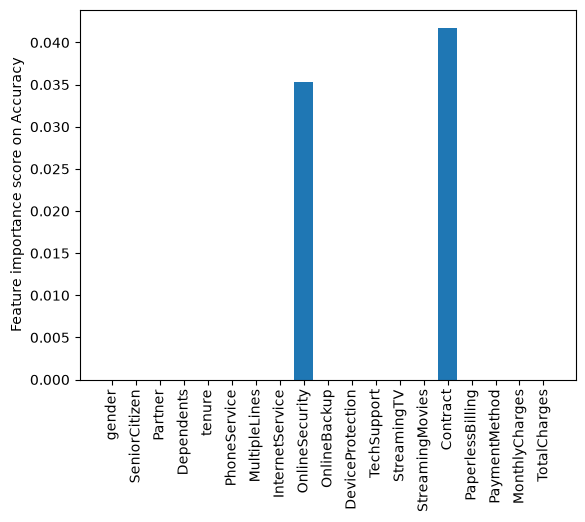

In [50]:
def plot_feature_importances(importance_scores, metric):
    """Plot feature importances."""
    labels = importance_scores.keys()
    importances = importance_scores.values()
    plt.bar(labels,importances)
    plt.tick_params("x", rotation=90, rotation_mode="xtick")
    plt.ylabel(f"Feature importance score on {metric}")
    plt.show()

plot_feature_importances(importance_scores,"Accuracy")

We see here that for the best found decision tree model, we have two columns which decide the entire effectivity of the model, namely `OnlineSecurity`and the `Contract` features, favouring Contract type.

We can do the same for the Sklearn decision tree to see how they evaluate importances' differently.

In [51]:
importance_scores = permutation_importance(best_decision_tree,x_test,y_test, accuracy_score, n_repeats=30, seed=seed)

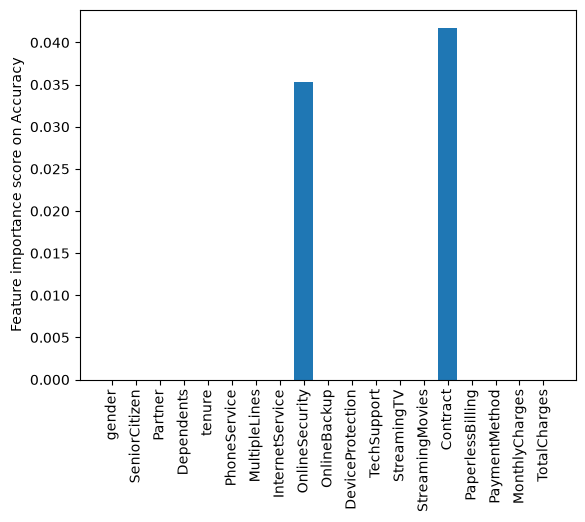

In [52]:
plot_feature_importances(importance_scores, "Accuracy")

They use the same features and have almost identical weights on each feature, it is important to note that behind-the-scenes, the different models have found different thresholds. Our custom decision tree implementation only uses the median, whilst sklearn uses the optimal one with regards to midpoints. 

The feature importance scores scores are dominated by two features, namely `Contract` and `OnlineSecurity`. Every other feature, including the tenure, monthly charges, and all the suspected important features discussed in EDA, has an importance score near or at zero. This implies that for these particular trees, the models' predictive power comes almost entirely from these two features, and that permuting any of the other eighteen columns has essentially no effect on the model's accuracy.

This is consistent with the trees' structures, with `max_depth=2`, the tree has at most four leaves, and it can have at most split on three features. If `Contract` and `OnlineSecurity` are the top two gain at the the root and first level, the tree simply never reaches the other columns, so their importance scores are exactly zero. The two nonzero scores reflect the only two features the tree actually uses.

This makes quite a lot of sense for a churn model, `Contract` captures which contract-type the customer is on (month-to-month, one year, etc...), and `OnlineSecurity` captures whether the customer subscribes to the online security add-on. Both are strong churn signals, that a shallow tree can latch onto quickly.

-------------------------


## Known flaws of feature importance scorings.

It must be noted that there are inherent weaknesses that this method of scoring features' importances posess.
1. First of all, correlated/redudant features gets underestimated since a model that corrupts/permuattes one of the correlated features can rely on the other uncorrupted correlated column to gain the same information. In this way, these two correlated columns can show up as having little to none feature importance simply due to them being correlated and the way the algorithm only corrupts one feature column at a time.

2. Might produce unrealistic/impossible permutations of datapoints. Since a dataset might have rules that govern the different features, we might have a possiblity of creating permutations of features that simply can not occur in a real test set. For example, if a dataset has a feature "married (boolean / yes or no)", and another "years since current marriage start (positive int)", permutating this might end up in a case where we have an individual who is not married, but has been in a marriage for the last 10 years. This simply can not occur in any real set and then can give an unrealistic image of the features' importances due to unrealistic modelling.

3. Sensitivity to high variance features. Features with high variance can create artificially high feature importance scores since shuffling them around inherently creates larger, more disruptive changes to the scoring metrics.

4. Creates an image of how important a feature is to the model, not the underlying process trying to be modelled. Therefore, creating a potentially unrepresentative image of the process, especially considering possible underfitting and overfitting which is never accounted for.

5. Interaction effects are not represented in the feature importance scores. This is important, since the interaction might be what actually matters and not the individual features the interaction is made up of on their own. This is especially prominent in decision trees and similar models.

6. Can be computationally expensive for larger models, due to the need to permutate each feature multiple times. For example here we have, 20*30=600 total feature permutations, each consisting of 7000 shuffles.

7. Only really gives a relative view of features on a chosen specific model, not actually on the underlying process. Another model might evaluate a minor feature as a feature with a much higher feature score.